### ☀️ 참고 ☀️ 한글깨짐 방지

- 아래 코드셀 3개 실행 필수
- 윈도우, 맥 동일

❗️주의❗️
- Step1. 첫째 셀 실행
- Step2. '런타임 > 세션 다시시작'
- Step3. 이후 두번째 셀 실행

In [ ]:
# 나눔 폰트 설치
# 해당 셀 실행 후 '런타임 > 세션 다시 시작'

#%%capture

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl


# 나눔고딕 폰트 사용 설정 (폰트 설치 후 실행)
plt.rcParams["font.family"]="NanumGothic"

# 마이너스 깨짐 방지 (일반 하이픈(-)을 사용하게 설정)
mpl.rcParams['axes.unicode_minus'] = False

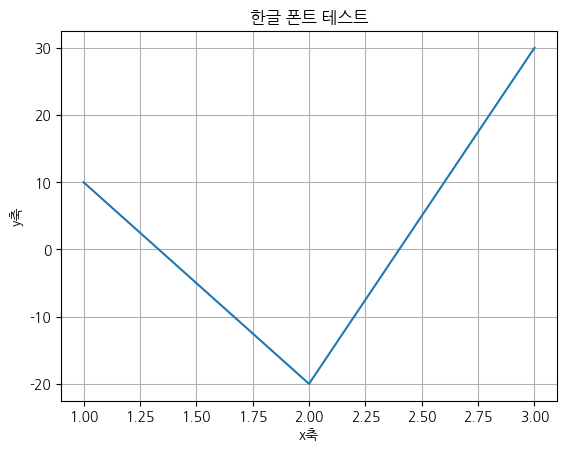

In [2]:
# 한글 폰트 테스트 그래프

plt.plot([1, 2, 3], [10, -20, 30])
plt.title('한글 폰트 테스트')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.show()

# 📘 CH03-03. 비지도 학습 및 모델 성능 향상 — 강의용 노트북

⚠️ 이번 챕터도 다루는 내용이 많아 정규 4시간을 넘어갈 수 있습니다.
Notion(md) 문서와 동일한 깊이로 구성했습니다 (🌙 더 깊이 알아보기 자율학습 섹션만 제외).

01. 비지도학습(클러스터링 등) · 02. Feature Importance와 Classification Report · 03. GridSearchCV와 Cross Validation · 04. 과적합·과소적합과 하이퍼파라미터

> 🔄 **개정 안내**: 이번 개정판부터는 하루 전체가 하나의 스토리로 이어집니다.
> - 오전(비지도학습): 쇼핑몰 **OO몰**의 마케팅 데이터 분석가가 되어 고객을 자동으로 그룹핑합니다.
> - 오후(성능 향상): 어제 만든 **OO전자 퇴사 예측 모델**을 이어받아 "왜 그렇게 판단했는지", "이 성능이 진짜인지"를 파헤칩니다.
> - 마무리(보너스): K-Means로 **내 사진의 색상 팔레트**를 직접 추출해봅니다.
> - 실습파일: `mall_customers.csv`, `hr_attrition.csv`(어제 배포한 파일 그대로), `sample_photo.jpg` — 모두 사전 배포
> - 🖥️ 라이브 데모와 🎁 보너스 소단원은 진도 상황에 따라 건너뛸 수 있는 독립 구성이며, 정규 4시간 개념 진도에 포함되지 않습니다.

---

# 📘 CH03-03-01. 비지도학습 (클러스터링 등)

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 비지도학습 복습 → K-Means 클러스터링 → 최적 클러스터 개수 찾기(Elbow·Silhouette) → PCA로 시각화 → DBSCAN 소개 → K-Means vs DBSCAN 비교
> 🔧 **실습파일**: 필요 (`mall_customers.csv` — 사전 배포)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-01-02(지도/비지도/강화학습)

---

## 🤔 먼저 생각해보기

> **여러분은 쇼핑몰 OO몰의 마케팅 데이터 분석가입니다. 마케팅팀장이 이렇게 요청합니다 — "고객마다 성향이 다른데 전부 똑같은 쿠폰을 보내고 있어요. 비슷한 고객끼리 자동으로 그룹을 나눠주세요. 단, 누가 VIP인지 정답표 같은 건 없습니다." 정답(라벨)이 없는데, 어떻게 그룹을 나눌 수 있을까요?**

정답(라벨) 없이 데이터의 특성만으로 비슷한 것끼리 묶는 것이 **군집화(Clustering)**입니다. 오늘은 CH03-01-02에서 개념만 살짝 다뤘던 비지도학습을, 실제 쇼핑몰 고객 데이터로 직접 구현해봅니다.

> 💡 이번 챕터는 고객 세분화(Customer Segmentation) 입문의 정석 데이터셋인 Mall Customers(고객 200명: 나이·연소득·소비점수)를 사용합니다. "라벨이 없는 진짜 비지도 상황"을 그대로 체험할 수 있는 소재입니다.

---

## 📖 핵심 개념

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 사전 배포된 실습파일을 노트북과 같은 폴더에 두고 실행하세요 (Colab: 왼쪽 파일 탭에 업로드)
df = pd.read_csv("mall_customers.csv")
print(df.head())

# 군집화에 사용할 특성 3개 (고객ID는 식별자, 성별은 이번 실습에서 제외)
X = df[["나이", "연소득_천달러", "소비점수"]]
print(X.describe().round(1))
```

</details>

In [7]:
# 코드 입력

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# csv 데이터 불러오기
#df = pd.read_csv('mall_customers.csv')
#print(df.shape)
#display(df.head())
#print(df.info())

# 데이터 준비하기
# 군집화에 사용할 특성 3개 (고객ID는 식별자, 성별은 이번 실습에서 제외)
X = df[['나이', '연소득_천달러', '소비점수']]
print(X.describe().round(1))


          나이  연소득_천달러   소비점수
count  200.0    200.0  200.0
mean    38.8     60.6   50.2
std     14.0     26.3   25.8
min     18.0     15.0    1.0
25%     28.8     41.5   34.8
50%     36.0     61.5   50.0
75%     49.0     78.0   73.0
max     70.0    137.0   99.0


### 1) K-Means 클러스터링 — 가장 대표적인 군집화 알고리즘

**동작 원리 (직관)**
1. 몇 개의 그룹(K개)으로 나눌지 미리 정함
2. 무작위로 K개의 중심점(centroid)을 찍음
3. 각 데이터를 "가장 가까운 중심점"의 그룹으로 배정
4. 각 그룹의 실제 평균 위치로 중심점을 이동
5. 3~4번을 중심점이 더 이상 움직이지 않을 때까지 반복

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.cluster import KMeans

# 우선 5개 그룹으로 나눠봅니다 (K를 왜 5로 정했는지는 잠시 뒤 Elbow·Silhouette에서 근거를 확인합니다)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)   # 각 고객이 어느 그룹(0~4)에 속하는지

print(cluster_labels[:10])
print("각 중심점의 좌표(나이·연소득·소비점수):\n", kmeans.cluster_centers_.round(1))
```

</details>

In [9]:
# 라이브러리 불러오기
from sklearn.cluster import KMeans

# 우선 5개 그룹으로 나누기
# K를 왜 5로 정했는지는 잠시 뒤 Elbow·Silhouette에서 근거를 확인합니다
kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
cluster_labels = kmeans.fit_predict(X)

print(cluster_labels[:10])
print('각 중심점의 좌표\n', kmeans.cluster_centers_.round(1))

[0 4 0 4 0 4 0 4 0 4]
각 중심점의 좌표
 [[45.2 26.3 20.9]
 [43.1 55.3 49.6]
 [32.7 86.5 82.1]
 [40.7 87.8 17.6]
 [25.5 26.3 78.6]]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 원본 데이터에 군집 번호 추가
df["cluster"] = cluster_labels

# 3D 그래프 생성
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 고객 데이터 표시
scatter = ax.scatter(
    df["나이"],
    df["연소득_천달러"],
    df["소비점수"],
    c=df["cluster"],      # 군집 번호에 따라 색상 구분
    cmap="tab10",
    s=50,
    alpha=0.7
)

# 군집 중심점 표시
centers = kmeans.cluster_centers_

ax.scatter(
    centers[:, 0],       # 나이
    centers[:, 1],       # 연소득
    centers[:, 2],       # 소비점수
    c="red",
    s=250,
    marker="X",
    edgecolors="black",
    label="Cluster Center"
)

# 축 제목
ax.set_xlabel("나이")
ax.set_ylabel("연소득(천 달러)")
ax.set_zlabel("소비점수")
ax.set_title("고객 군집화 결과 - 3D 산점도")

# 범례
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
ax.legend(loc="upper left")

plt.show()
```

</details>

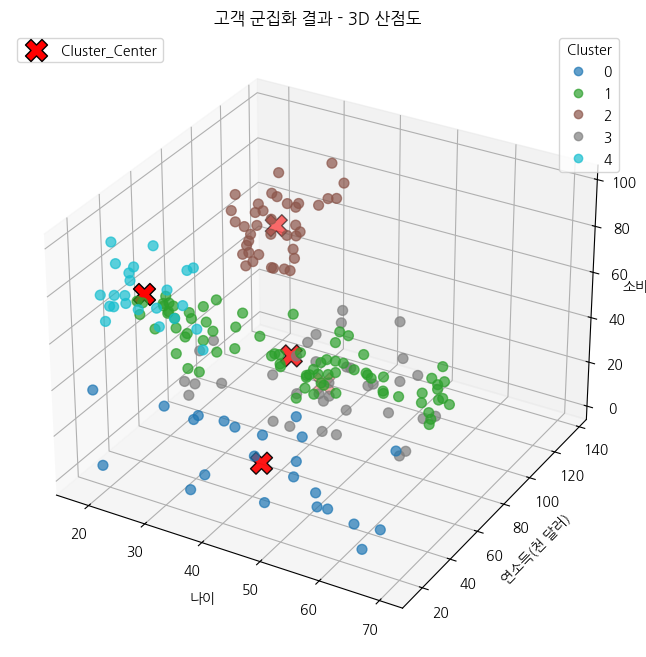

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 원본 데이터에 군집 번호 추가
df['cluster'] = cluster_labels

# 3D 그래프 생성
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

# 고객 데이터 표시
scatter = ax.scatter(df['나이'], df['연소득_천달러'], df['소비점수'], c = df['cluster'], cmap = 'tab10', s = 50, alpha = 0.7)

# 군집 중심점 표시
centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c = 'red', s = 250, marker = 'X', edgecolors = 'black', label = "Cluster_Center")



# 축 제목
ax.set_xlabel("나이")
ax.set_ylabel("연소득(천 달러)")
ax.set_zlabel("소비점수")
ax.set_title("고객 군집화 결과 - 3D 산점도")

# 범례
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
ax.legend(loc="upper left")

plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 정답이 없으므로, 그룹별 "평균 프로필"을 뽑아 각 그룹이 어떤 고객인지 직접 해석합니다
profile = df.assign(그룹=cluster_labels).groupby("그룹")[["나이", "연소득_천달러", "소비점수"]].mean().round(1)
profile["인원"] = pd.Series(cluster_labels).value_counts().sort_index()
print(profile)
```

</details>

In [15]:
# 정답이 없으므로, 그룹별 "평균 프로필"을 뽑아 각 그룹이 어떤 고객인지 직접 해석합니다

profile = df.assign(그룹=cluster_labels).groupby("그룹")[["나이", "연소득_천달러", "소비점수"]].mean().round(1)
profile["인원"] = pd.Series(cluster_labels).value_counts().sort_index()
display(profile)


,나이,연소득_천달러,소비점수,인원
그룹,,,,
0,45.2,26.3,20.9,23
1,43.1,55.3,49.6,79
2,32.7,86.5,82.1,39
3,40.7,87.8,17.6,36
4,25.5,26.3,78.6,23


> 💡 프로필 표를 읽어보면 그룹의 정체가 보입니다 — "젊고 소득도 소비도 높은 그룹(VIP)", "소득은 높은데 소비가 적은 그룹(잠재 VIP, 유치 대상)", "소득은 낮지만 소비가 활발한 젊은 그룹"처럼요. 정답 라벨 없이도 이렇게 **프로파일링으로 그룹에 이름을 붙이는 것**이 실무 고객 세분화의 핵심 작업입니다.

### 2) 최적의 클러스터 개수(K) 찾기 — Elbow Method

- K를 몇 개로 해야 할지는 K-Means 스스로는 알려주지 않으므로, 직접 판단해야 함
- **관성(inertia)**: 각 데이터와 자신이 속한 중심점 사이 거리의 총합 (작을수록 그룹이 잘 뭉쳐 있음)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.xlabel("클러스터 개수(K)")
plt.ylabel("Inertia(군집 내 거리 총합)")
plt.title("Elbow Method")
plt.show()
```

</details>

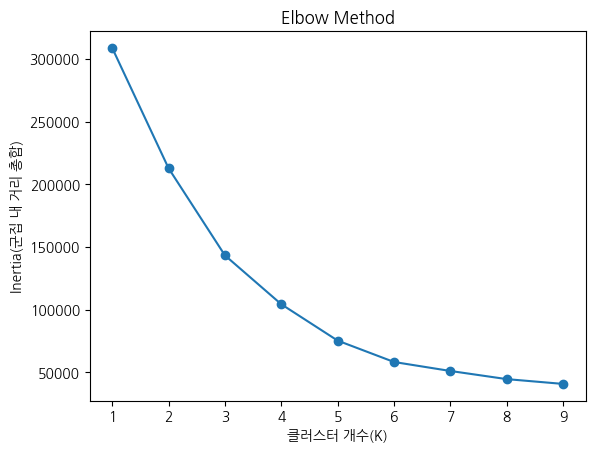

In [16]:
# 코드 입력
inertias = []
K_range = range(1, 10)

# k값이 1부터 9까지 돌아가며 만들어보자.
for k in K_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")

plt.xlabel("클러스터 개수(K)")
plt.ylabel("Inertia(군집 내 거리 총합)")
plt.title("Elbow Method")

plt.show()

> 💡 그래프에서 감소폭이 급격히 줄어들며 "팔꿈치(elbow)"처럼 꺾이는 지점이 적절한 K값의 후보입니다.
- k = 1~5: inertia가 크게 감소
- k = 5 이후: 감소폭이 눈에 띄게 줄어듦
- 결론: 5개의 군집으로 나누는 것이 적절하다고 판단할 수 있음

### 3) Silhouette Score — 군집화 품질을 숫자로 평가

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}: Silhouette Score={score:.4f}")

# K=5와 K=6의 점수가 비슷하게 높게 나옵니다 — 이럴 땐 Elbow의 꺾임 지점과
# "그룹을 몇 개로 나눠야 해석·활용하기 좋은가"(비즈니스 관점)까지 함께 고려해 결정합니다. 우리는 K=5 채택.
```

</details>

In [17]:
# 코드 입력
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'K = {k}: 실루엣 스코어: {score:.4f}')

# K=5와 K=6의 점수가 비슷하게 높게 나옵니다 — 이럴 땐 Elbow의 꺾임 지점과
# "그룹을 몇 개로 나눠야 해석·활용하기 좋은가"(비즈니스 관점)까지 함께 고려해 결정합니다. 우리는 K=5 채택.

K = 2: 실루엣 스코어: 0.2932
K = 3: 실루엣 스코어: 0.3839
K = 4: 실루엣 스코어: 0.4055
K = 5: 실루엣 스코어: 0.4443
K = 6: 실루엣 스코어: 0.4523
K = 7: 실루엣 스코어: 0.4388


> 💡 Silhouette Score는 -1~1 사이 값으로, 1에 가까울수록 "같은 그룹끼리는 가깝고, 다른 그룹과는 멀리 떨어져 있다"는 뜻이라 군집화가 잘 되었다고 볼 수 있습니다.

| Silhouette Score | 해석                   |
| ---------------: | -------------------- |
|        0.7 ~ 1.0 | 매우 우수 (군집이 아주 뚜렷함)   |
|        0.5 ~ 0.7 | 좋은 군집                |
|   **0.25 ~ 0.5** | **무난한 군집 (실무에서 흔함)** |
|         0 ~ 0.25 | 군집이 애매함              |
|              < 0 | 잘못 군집화되었을 가능성        |



### 4) PCA로 고차원 데이터를 2차원으로 시각화하기

- 우리 데이터는 특성이 3개(나이·연소득·소비점수)라 3차원 공간의 점들 → 차원 축소(PCA)로 2개 축으로 압축하면 한 화면에 그릴 수 있음
- 즉, PCA는 이미 만들어진 군집을 사람이 보기 쉽게 2차원으로 표현한 것
- PCA는 기존 특성들을 "가중합(선형결합)"해서 새로운 축을 만드는 방법
- 많이 퍼져있는 방향을 찾자. 분산이 높은 방향 =  데이터들을 가장 잘 구분해주는 방향
- 예시) 주성분1 = 0.42×나이 + 0.65×연소득 + 0.63×소비점수
- 예시) 주성분2 = -0.88×나이 + 0.32×연소득 - 0.35×소비점수

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis")
plt.xlabel("주성분 1")
plt.ylabel("주성분 2")
plt.title("K-Means 클러스터링 결과 (PCA로 2차원 시각화)")
plt.colorbar(scatter, label="클러스터")
plt.show()
```

</details>

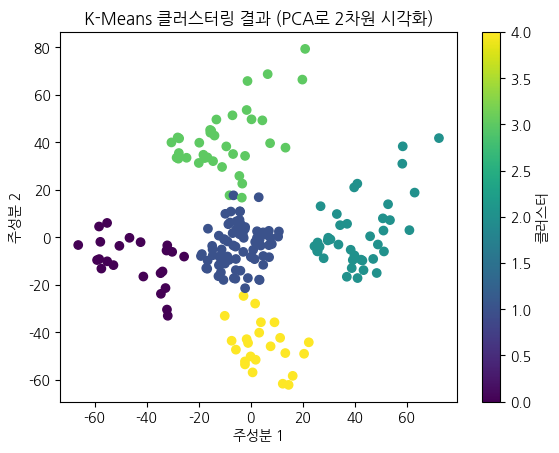

In [20]:
# 라이브러리 불러오기
from sklearn.decomposition import PCA

# 주성분을 2개로 줄이도록 PCA 객체 생성
# (원래 3개의 특성을 → 2개의 새로운 축으로 압축)
pca = PCA(n_components = 2)

# PCA 학습(fit)과 데이터 변환(transform)을 한 번에 수행
# 결과는 (주성분1, 주성분2)로 이루어진 새로운 좌표
X_pca = pca.fit_transform(X)

# PCA로 변환된 2차원 데이터를 산점도로 시각화
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = cluster_labels, cmap = 'viridis')

plt.title("K-Means 클러스터링 결과 (PCA로 2차원 시각화)")
plt.xlabel("주성분 1")
plt.ylabel("주성분 2")

# 군집 번호에 대응되는 색상 범례 표시
plt.colorbar(scatter, label="클러스터")

# 그래프 출력
plt.show()

### 5) DBSCAN — 밀도 기반 군집화 (다른 접근 방식 소개)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.cluster import DBSCAN

# eps는 "거리"라서 데이터의 단위에 따라 달라집니다 (나이·소득·점수 단위 기준으로 12가 적절)
dbscan = DBSCAN(eps=12, min_samples=5)   # eps: 이웃으로 볼 거리, min_samples: 군집으로 볼 최소 개수
dbscan_labels = dbscan.fit_predict(X)

print(np.unique(dbscan_labels))   # -1은 "어느 그룹에도 속하지 않는 노이즈"를 의미
print(pd.Series(dbscan_labels).value_counts())
```

</details>

In [21]:
# 라이브러리 불러오기
from sklearn.cluster import DBSCAN

# eps: 이웃으로 볼 거리, min_samples: 군집으로 볼 최소 개수
# eps는 "거리"라서 데이터의 단위에 따라 달라집니다 (나이·소득·점수 단위 기준으로 12가 적절 > 이미 계산)
# 현재 데이터에 적합하도록 미리 선택한 eps 값
dbscan = DBSCAN(eps = 12, min_samples = 5)
dbscan_labels = dbscan.fit_predict(X)

print(np.unique(dbscan_labels))   # -1은 "어느 그룹에도 속하지 않는 노이즈"를 의미
print(pd.Series(dbscan_labels).value_counts())


[-1  0  1  2  3  4]
 0    101
-1     36
 3     34
 4     17
 2      6
 1      6
Name: count, dtype: int64


### 6) 서로 다른 군집화 방식 비교 — K-Means vs DBSCAN

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis")
axes[0].set_title("K-Means (K=5)")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="viridis")
axes[1].set_title("DBSCAN")
plt.show()
```

</details>

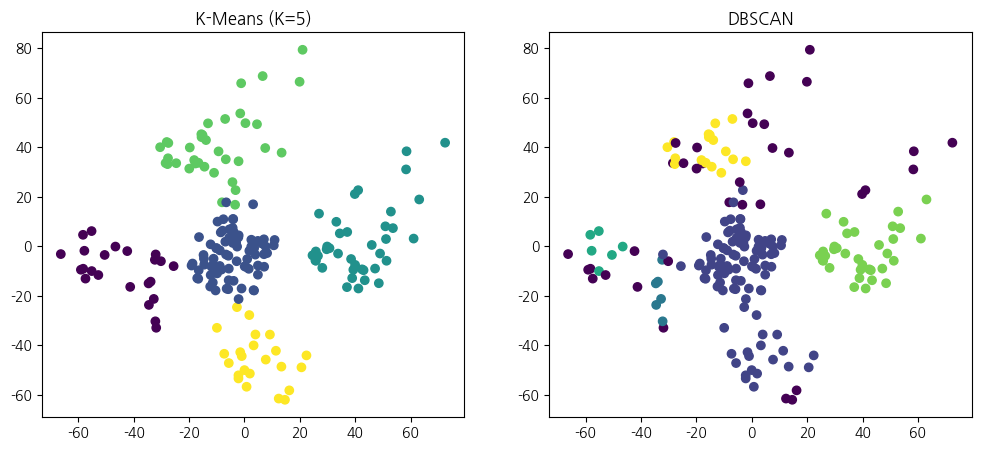

In [22]:
# 코드 입력

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis")
axes[0].set_title("K-Means (K=5)")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="viridis")
axes[1].set_title("DBSCAN")
plt.show()


| 구분 | K-Means | DBSCAN |
|---|---|---|
| 클러스터 개수 | 미리 지정해야 함(K) | 자동으로 결정됨 (eps, min_samples로 간접 조절) |
| 클러스터 모양 가정 | 원형/구형에 가까운 그룹을 잘 찾음 | 임의의 모양(길쭉하거나 복잡한 형태)도 잘 찾음 |
| 이상치(노이즈) 처리 | 모든 점을 반드시 어떤 그룹에 배정 | 어느 그룹에도 속하지 않는 "노이즈"로 분류 가능(-1) |
| 언제 사용? | 그룹 개수를 대략 알고 있고, 데이터가 뭉쳐있는 형태일 때 | 그룹 개수를 모르고, 이상치를 자동으로 걸러내고 싶을 때 |

> 💡 **핵심 요약**: 그룹의 개수를 어느 정도 예상할 수 있고 데이터가 구형으로 뭉쳐있다면 K-Means가 간단하고 빠릅니다. 그룹 개수를 모르거나 이상치를 함께 걸러내고 싶다면 DBSCAN이 더 적합합니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ K-Means의 K값을 아무 근거 없이 정해서 사용하는 경우가 흔합니다 — Elbow Method나 Silhouette Score로 근거를 마련하는 것이 좋습니다.

> ⚠️ 특성들의 스케일이 크게 다른 상태로 K-Means를 적용해서 특정 특성이 거리 계산을 지배하는 경우가 있습니다 — CH10에서 배운 스케일링을 군집화 전에 적용하는 것이 일반적입니다. (오늘 데이터는 세 특성의 범위가 비슷해서 그대로 사용했습니다 — 실습 과제에서 직접 비교해봅니다.)

> ⚠️ 오늘 우리 데이터처럼 실제 비지도학습 상황에는 정답 라벨이 아예 없으므로, "몇 % 맞았다"는 식의 검증이 불가능합니다 — 대신 Silhouette Score(수치)와 그룹 프로파일링(해석)으로 군집의 품질을 판단해야 합니다.

---

## 🚀 실무에서는?

> 🚀 고객 세분화(마케팅), 이상 거래 탐지의 사전 분석, 유사 상품 그룹화 등에 K-Means와 같은 군집화 기법이 널리 사용됩니다. 실무에서는 군집화 전에 반드시 스케일링을 적용하고, Silhouette Score와 그룹 프로파일링으로 군집 품질을 검증한 뒤, 각 그룹에 "가성비형", "프리미엄형" 같은 마케팅 페르소나 이름을 붙여 캠페인에 활용합니다.

---

## 🧩 Check Point

**Q1.** K-Means에서 반드시 미리 지정해야 하는 값은? ① eps ② K(클러스터 개수) ③ min_samples ④ 필요 없음
<details><summary>정답</summary>② K(클러스터 개수)</details>

**Q2.** 클러스터 개수를 자동으로 결정하고 이상치를 노이즈로 분류할 수 있는 알고리즘은? ① K-Means ② DBSCAN
<details><summary>정답</summary>② DBSCAN</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [ ]:
# TODO 1 (K-Means 기본): mall_customers.csv의 세 특성(나이·연소득·소비점수)에 K=5인 K-Means를 적용하고 그룹별 인원을 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.cluster import KMeans
import pandas as pd

df = pd.read_csv("mall_customers.csv")
X = df[["나이", "연소득_천달러", "소비점수"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
print(pd.Series(labels).value_counts())
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 2 (Elbow Method): K=1~8까지 inertia를 계산해 그래프로 그리세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
plt.plot(range(1, 9), inertias, marker="o")
plt.show()
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 3 (Silhouette Score): K=2~6에서의 Silhouette Score를 각각 계산하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import silhouette_score
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    print(k, silhouette_score(X, labels_k))
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 4 (PCA 시각화): 고객 데이터를 PCA로 2차원 축소해 K-Means 결과를 시각화하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.show()
```

</details>

In [ ]:
# 코드 입력




---

## 📝 실습 과제

In [ ]:
# 과제 1: K=5 클러스터 결과를 그룹별로 프로파일링(평균 나이·연소득·소비점수)하고,
#         각 그룹에 어울리는 마케팅 페르소나 이름(예: "VIP", "잠재 VIP")을 주석으로 붙여보세요

# 과제 2: 세 특성에 스케일링(StandardScaler)을 적용한 후와 적용하지 않은 상태에서
#         각각 K-Means(K=5)를 수행해 Silhouette Score와 그룹 인원 구성이 어떻게 달라지는지 비교해보세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
profile = df.assign(그룹=labels).groupby("그룹")[["나이", "연소득_천달러", "소비점수"]].mean().round(1)
profile["인원"] = pd.Series(labels).value_counts().sort_index()
print(profile)
# 해석 예: 소득·소비 모두 높은 그룹 → "VIP" / 소득은 높은데 소비가 낮은 그룹 → "잠재 VIP(유치 대상)"
#          젊고 소비가 활발한 그룹 → "트렌드 소비형" / 소득·소비 모두 낮은 그룹 → "절약형"
```

</details>

In [ ]:
# 과제 1 예시 정답






# 해석 예: 소득·소비 모두 높은 그룹 → "VIP" / 소득은 높은데 소비가 낮은 그룹 → "잠재 VIP(유치 대상)"
#          젊고 소비가 활발한 그룹 → "트렌드 소비형" / 소득·소비 모두 낮은 그룹 → "절약형"


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X_scaled = StandardScaler().fit_transform(X)

labels_unscaled = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)
labels_scaled = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled)

print("스케일링 전 Silhouette:", round(silhouette_score(X, labels_unscaled), 3))
print("스케일링 후 Silhouette:", round(silhouette_score(X_scaled, labels_scaled), 3))
print("스케일링 전 인원:", pd.Series(labels_unscaled).value_counts().sort_index().tolist())
print("스케일링 후 인원:", pd.Series(labels_scaled).value_counts().sort_index().tolist())
# 스케일링 후에는 세 특성이 동등한 비중으로 거리 계산에 반영되어 그룹 구성이 달라짐
```

</details>

In [ ]:
# 과제 2 예시 정답





# 스케일링 후에는 세 특성이 동등한 비중으로 거리 계산에 반영되어 그룹 구성이 달라짐


---

## 📌 핵심 정리

- K-Means: 중심점을 반복적으로 이동시키며 K개의 그룹으로 나누는 대표적 군집화 알고리즘
- Elbow Method(inertia), Silhouette Score로 적절한 K값 탐색
- 정답이 없으므로 그룹 프로파일링(평균 프로필 해석)으로 각 군집에 의미를 부여
- PCA로 고차원 데이터를 2차원으로 압축해 시각화
- DBSCAN: 클러스터 개수를 자동 결정, 밀도 기반, 노이즈(이상치) 자동 분류
- 군집화 전에는 스케일링을 적용하는 것이 일반적

---

---

# 🖥️ 라이브 데모 — 고차원 데이터를 눈으로 탐험하기

> ⏭️ 이 섹션은 진도 상황에 따라 건너뛸 수 있는 독립 코너입니다.

방금 배운 PCA가 실제로 어떤 일을 하는지, 구글이 만든 인터랙티브 도구로 확인해봅니다. 손글씨 숫자(MNIST) 1만 장이 3차원 공간에 뿌려져 있고, 마우스로 돌려가며 탐험할 수 있습니다.

**🔗 접속 주소**: [Embedding Projector (Google)](https://projector.tensorflow.org/)

**함께 보는 포인트**
1. 처음 화면의 점 하나하나가 손글씨 이미지 1장입니다 — 784차원(28×28픽셀)을 PCA로 3차원까지 압축한 결과
2. 비슷한 숫자끼리 뭉쳐 있는 덩어리들 — 우리가 방금 고객 데이터에서 본 "군집"이 눈앞에서 3D로 보이는 것
3. 왼쪽 하단에서 T-SNE로 바꿔보면 군집이 훨씬 뚜렷하게 분리됩니다 (PCA와는 다른 방식의 차원 축소)

**✏️ 자유 체험**: 채팅으로 공유된 링크에 접속해 마우스로 회전·확대하며 자유롭게 탐험해보세요. 점을 클릭하면 실제 손글씨 이미지가 보입니다.

> 💡 예비 링크: [Visualizing K-Means Clustering](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/) — 오늘 배운 K-Means의 중심점 이동 과정을 직접 클릭하며 한 단계씩 진행해볼 수 있는 인터랙티브 데모

---

# 📘 CH13-02. Feature Importance와 Classification Report

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: Feature Importance란? → 트리 기반 내장 중요도 → Permutation Importance → 다중 클래스 Classification Report → 내장 중요도 vs Permutation Importance 비교
> 🔧 **실습파일**: 필요 (`hr_attrition.csv` — 어제 배포한 파일 그대로)
> ⏱️ **예상 소요시간**: 40분
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-02(회귀와 분류 모델)

---

## 🤔 먼저 생각해보기

> **어제 여러분이 만든 퇴사 예측 모델을 본 인사팀장이 묻습니다 — "그래서, 이 모델은 뭘 보고 퇴사한다고 판단하는 건가요? 야근인가요, 월급인가요?" 성능 숫자만으로는 이 질문에 답할 수 없습니다. 모델의 판단 근거를 어떻게 꺼내볼 수 있을까요?**

모델이 왜 그렇게 예측했는지 이해하는 것은 성능만큼이나 중요합니다. 이번 챕터에서는 어제 만든 퇴사 예측 모델을 그대로 이어받아, 어떤 특성이 예측에 얼마나 기여했는지 확인하는 **Feature Importance**와, 분류 모델을 다중 클래스(3개 이상)에서 평가하는 방법을 다룹니다.

---

## 📖 핵심 개념

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제(CH03-02) 만든 퇴사 예측 모델을 동일하게 다시 준비합니다
df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
```

</details>

In [25]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제(CH03-02) 만든 퇴사 예측 모델을 동일하게 다시 준비합니다
df = pd.read_csv("hr_attrition.csv")

# Step1. 필요없는 컬럼 삭제 ("EmployeeNumber", "EmployeeCount", "StandardHours", "Over18")
# errors="ignore" 옵션 추가
df = df.drop(columns = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors = "ignore")

# Step2. 목표변수 인코딩 (레이블 인코딩)
df['Attrition'] = df['Attrition'].map({"Yes":1, "No":0})

# Step3. 원핫 인코딩 (모든 범주형 변수) (columns 옵션을 안넣을 경우 모든 범주형 변수가 인코딩 됨)

# Step4. X, y 데이터 분리
X, y = pd.get_dummies(df.drop(columns = 'Attrition'), drop_first = True), df['Attrition']

# Step5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Step6. 모델 생성 및 학습 (RandomForestClassifier, n_estimators = 100, random_state = 42)
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 1) 트리 기반 모델의 내장 Feature Importance

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)
```

</details>

In [26]:
# 코드 입력
importance = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending = False)
print(importance)

MonthlyIncome                        0.072306
Age                                  0.072260
TotalWorkingYears                    0.053589
DailyRate                            0.051670
HourlyRate                           0.047866
DistanceFromHome                     0.047793
MonthlyRate                          0.047228
YearsAtCompany                       0.044137
OverTime_Yes                         0.037830
YearsWithCurrManager                 0.035452
NumCompaniesWorked                   0.035212
PercentSalaryHike                    0.033997
EnvironmentSatisfaction              0.027282
TrainingTimesLastYear                0.026506
YearsInCurrentRole                   0.026050
StockOptionLevel                     0.025908
JobSatisfaction                      0.024757
WorkLifeBalance                      0.024655
JobInvolvement                       0.023972
YearsSinceLastPromotion              0.023601
RelationshipSatisfaction             0.022431
JobLevel                          

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 10)")
plt.gca().invert_yaxis()
plt.show()
```

</details>

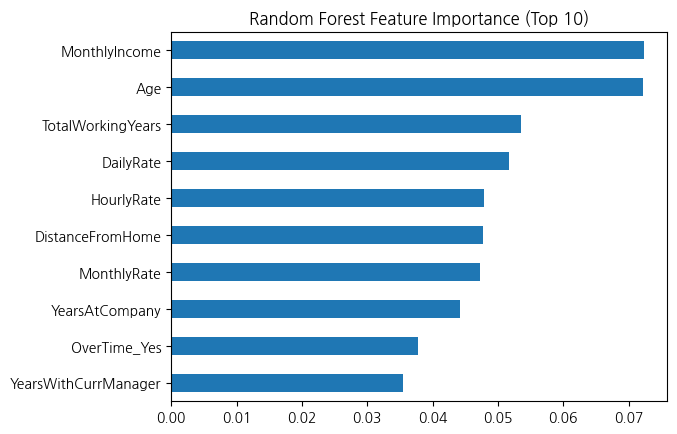

In [27]:
# 코드 입력

import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 10)")
plt.gca().invert_yaxis() #Get Current Axes(현재 그래프를 가져와라), y축을 뒤집기
plt.show()


> 💡 트리 기반 모델의 `feature_importances_`는 "이 특성으로 분기했을 때 불순도(impurity)가 얼마나 줄어들었는지"를 기준으로 계산됩니다.

### 2) Permutation Importance — 더 신뢰할 수 있는 대안적 방법

- 특정 특성의 값을 무작위로 "섞어서" 일부러 망가뜨린 뒤, 모델 성능이 얼마나 나빠지는지로 중요도를 측정
- 즉, 이 특성을 망가뜨렸는데도 모델 성능이 안떨어진다면, 모델은 이 특성에 크게 의존하지 않는다는 아이디어.
- 트리 기반 모델뿐 아니라 **어떤 모델에도 적용 가능**(model-agnostic)하다는 큰 장점

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_importance)
```

</details>

In [29]:
# 코드 입력
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats = 10, random_state = 42)

perm_importance = pd.Series(result.importances_mean, index = X.columns).sort_values(ascending = False)
print(perm_importance)

OverTime_Yes                         0.007483
BusinessTravel_Travel_Frequently     0.002041
JobInvolvement                       0.001701
BusinessTravel_Travel_Rarely         0.001701
RelationshipSatisfaction             0.001701
EducationField_Medical               0.001361
YearsSinceLastPromotion              0.000680
TrainingTimesLastYear                0.000340
PerformanceRating                    0.000000
JobRole_Sales Executive              0.000000
JobRole_Manufacturing Director       0.000000
Gender_Male                          0.000000
EducationField_Marketing             0.000000
JobRole_Manager                      0.000000
JobRole_Research Director            0.000000
EducationField_Other                -0.000340
MaritalStatus_Married               -0.000340
EducationField_Technical Degree     -0.000340
JobRole_Human Resources             -0.000340
JobRole_Laboratory Technician       -0.000340
Department_Research & Development   -0.000680
MonthlyRate                       

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
perm_importance.head(10).plot(kind="barh")
plt.title("Permutation Importance (Top 10)")
plt.gca().invert_yaxis()
plt.show()
```

</details>

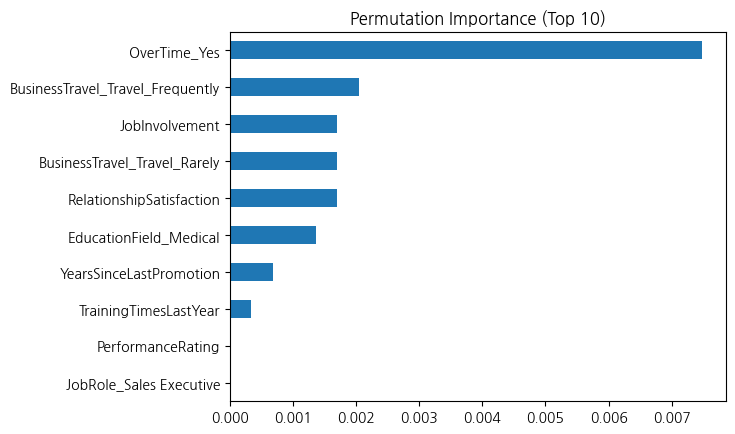

In [30]:
# 코드 입력

perm_importance.head(10).plot(kind="barh")
plt.title("Permutation Importance (Top 10)")
plt.gca().invert_yaxis()
plt.show()


### 3) 서로 다른 방식 비교 — 내장 Feature Importance vs Permutation Importance

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
comparison = pd.DataFrame({
    "내장 중요도(Impurity 기반)": importance,
    "Permutation 중요도": perm_importance
}).sort_values("내장 중요도(Impurity 기반)", ascending=False)
print(comparison.head(10))
```

</details>

In [31]:
# 코드 입력

comparison = pd.DataFrame({
    "내장 중요도(Impurity 기반)": importance,
    "Permutation 중요도": perm_importance
}).sort_values("내장 중요도(Impurity 기반)", ascending=False)
print(comparison.head(10))


                      내장 중요도(Impurity 기반)  Permutation 중요도
MonthlyIncome                    0.072306        -0.005782
Age                              0.072260        -0.015986
TotalWorkingYears                0.053589        -0.017007
DailyRate                        0.051670        -0.002381
HourlyRate                       0.047866        -0.007823
DistanceFromHome                 0.047793        -0.008844
MonthlyRate                      0.047228        -0.001020
YearsAtCompany                   0.044137        -0.011905
OverTime_Yes                     0.037830         0.007483
YearsWithCurrManager             0.035452        -0.013605


| 구분 | 내장 Feature Importance | Permutation Importance |
|---|---|---|
| 계산 방식 | 분기 시 불순도 감소량 누적 | 특성을 섞었을 때 성능 저하 정도 |
| 사용 가능 모델 | 트리 기반 모델만 (Decision Tree, RF, XGBoost 등) | 모든 모델에 적용 가능 (모델 구조 무관) |
| 계산 데이터 | 훈련 과정 중 자동 계산 (추가 데이터 불필요) | 별도로 테스트 데이터에 대해 계산 필요 |
| 신뢰도 | 특성 간 상관관계가 높으면 왜곡될 수 있음 | 상대적으로 더 신뢰할 수 있음(실제 예측 성능 기반) |
| 계산 비용 | 낮음(이미 계산되어 있음) | 상대적으로 높음(반복 계산 필요) |

> 💡 **핵심 요약**: 빠르게 대략적인 중요도를 보고 싶다면 내장 Feature Importance로 충분하지만, 더 신뢰할 수 있는 결과나 트리 기반이 아닌 모델(로지스틱 회귀 등)의 중요도가 필요하다면 Permutation Importance를 사용하세요.

### 4) 다중 클래스(3개 이상) Classification Report

CH12-04에서는 이진 분류(퇴사/재직)만 다뤘는데, 이번엔 3개 클래스로 확장합니다. 인사팀의 추가 요청 — "인사 DB에 부서(Department) 라벨이 누락된 직원들이 있어요. 다른 정보를 보고 어느 부서 소속인지 자동 분류해줄 수 있나요?" — R&D, 영업(Sales), 인사(HR) 3개 부서를 맞히는 다중 클래스 문제입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import classification_report

# 부서(3개 클래스)를 맞히는 두 번째 모델: 목표값만 Attrition → Department로 교체
y2 = df["Department"]
X2 = pd.get_dummies(df.drop(columns=["Department", "Attrition"]), drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X2_train, y2_train)

y2_pred = rf2.predict(X2_test)
print(classification_report(y2_test, y2_pred))
```

</details>

In [35]:
# 코드 입력

from sklearn.metrics import classification_report

# 부서(3개 클래스)를 맞히는 두 번째 모델: 목표값만 Attrition → Department로 교체
y2 = df["Department"]
X2 = pd.get_dummies(df.drop(columns=["Department", "Attrition"]), drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 42, stratify = y)
rf2 = RandomForestClassifier(n_estimators = 100, random_state = 42).fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)

print(classification_report(y2_test, y2_pred))


                        precision    recall  f1-score   support

       Human Resources       1.00      0.73      0.85        15
Research & Development       0.96      1.00      0.98       197
                 Sales       1.00      0.95      0.97        82

              accuracy                           0.97       294
             macro avg       0.99      0.89      0.93       294
          weighted avg       0.97      0.97      0.97       294



```
                        precision    recall  f1-score   support
Human Resources             1.00      0.85      0.92        13
Research & Development      0.98      0.99      0.99       192
Sales                       0.97      0.98      0.97        89

              accuracy                          0.98       294
             macro avg      0.98      0.94      0.96       294
          weighted avg      0.98      0.98      0.98       294
```
(실행 결과는 위와 유사하게 나옵니다)

**다중 클래스 리포트에서 새로 등장하는 개념**

| 용어 | 의미 |
|---|---|
| `support` | 각 클래스의 실제 테스트 데이터 개수 |
| `macro avg` | 각 클래스의 지표를 "단순 평균" (클래스 개수 차이 무시) |
| `weighted avg` | 각 클래스의 지표를 "클래스 개수 비율로 가중 평균" |

> 💡 support를 보세요 — 인사(HR)부서는 13명뿐이고 R&D는 192명입니다. 이런 클래스 불균형 상황에서 macro와 weighted의 차이가 왜 생기는지, 바로 아래에서 직접 계산해봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# macro와 weighted average의 차이를 직접 계산해서 확인
from sklearn.metrics import recall_score

macro_recall = recall_score(y2_test, y2_pred, average="macro")
weighted_recall = recall_score(y2_test, y2_pred, average="weighted")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
# 소수 클래스(HR, 13명)의 낮은 recall이 macro에는 그대로 반영되지만,
# weighted에서는 인원 비중(13/294)만큼만 반영되어 차이가 발생
```

</details>

In [36]:
# macro와 weighted average의 차이를 직접 계산해서 확인

from sklearn.metrics import recall_score

macro_recall = recall_score(y2_test, y2_pred, average = 'macro')
weighted_recall = recall_score(y2_test, y2_pred, average = 'weighted')

print(f"Macro Recall: {macro_recall:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")

# 소수 클래스(HR, 13명)의 낮은 recall이 macro에는 그대로 반영되지만,
# weighted에서는 인원 비중(13/294)만큼만 반영되어 차이가 발생

Macro Recall: 0.8949
Weighted Recall: 0.9728


> 💡 클래스별 데이터 개수가 크게 다르다면 `macro avg`와 `weighted avg`의 차이가 커집니다. 소수 클래스도 동등하게 중요하다면 `macro avg`를, 데이터 비율을 반영하고 싶다면 `weighted avg`를 참고하세요.

### 5) Confusion Matrix도 다중 클래스로 확장하기

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dept_names = sorted(y2.unique())
cm = confusion_matrix(y2_test, y2_pred, labels=dept_names)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dept_names, yticklabels=dept_names)
plt.xlabel("예측")
plt.ylabel("실제")
plt.title("3-Class Confusion Matrix (부서 분류)")
plt.show()
```

</details>

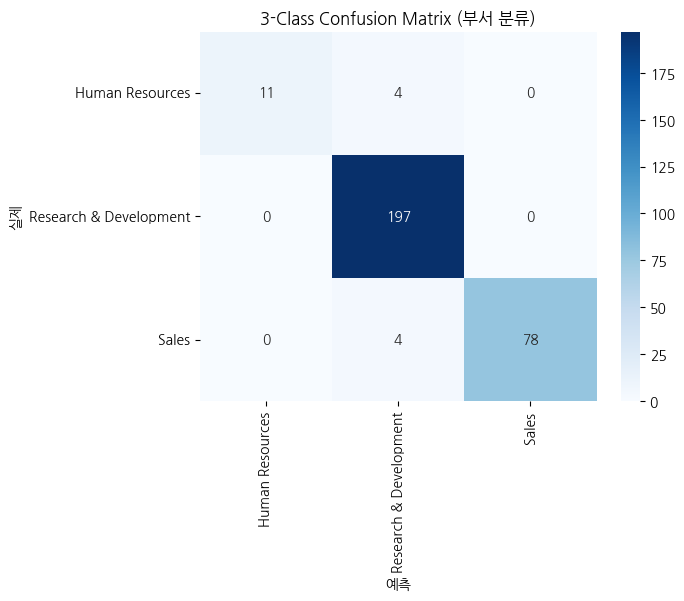

In [37]:
# 코드 입력

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dept_names = sorted(y2.unique())
cm = confusion_matrix(y2_test, y2_pred, labels=dept_names)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dept_names, yticklabels=dept_names)

plt.xlabel("예측")
plt.ylabel("실제")
plt.title("3-Class Confusion Matrix (부서 분류)")
plt.show()

---

## ⚠️ 자주 하는 실수

> ⚠️ 트리 기반 모델의 내장 Feature Importance를 "절대적인 진실"로 받아들이는 경우가 있는데, 상관관계가 높은 특성들 사이에서는 왜곡될 수 있습니다.

> ⚠️ 다중 클래스에서 `precision_score()` 등을 `average` 옵션 없이 호출하면 에러가 나거나 의도와 다른 결과가 나올 수 있습니다.

> ⚠️ Permutation Importance를 훈련 데이터가 아니라 테스트 데이터로 계산해야 하는데, 이를 혼동하는 경우가 있습니다 (모델이 "실제로 처음 보는 데이터"에서 어떤 특성에 의존하는지 확인해야 하므로).

---

## 🚀 실무에서는?

> 🚀 모델의 예측 근거를 설명해야 하는 금융·의료·HR 분야에서는 Feature Importance가 필수적으로 요구됩니다. 특히 퇴사 예측처럼 사람에 대한 판단이 걸린 문제에서는 "모델이 무엇을 근거로 판단했는가"를 설명할 수 없으면 결과를 활용할 수 없습니다. 다중 클래스 분류(상품 카테고리 분류, 고객 등급 분류 등)에서는 `macro avg`와 `weighted avg`를 함께 보고 소수 클래스의 성능이 무시되지 않는지 확인하는 것이 중요합니다.

---

## 🧩 Check Point

**Q1.** 어떤 모델에도 적용 가능한(model-agnostic) 중요도 계산 방법은? ① 내장 Feature Importance ② Permutation Importance
<details><summary>정답</summary>② Permutation Importance</details>

**Q2.** 클래스별 데이터 개수 비율을 반영해 평균을 계산하는 방식은? ① macro avg ② weighted avg
<details><summary>정답</summary>② weighted avg</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [ ]:
# TODO 1 (내장 중요도): 퇴사 예측 모델(rf)의 Feature Importance 상위 5개를 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
top5 = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
print(top5)
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 2 (Permutation Importance): 위 모델의 Permutation Importance를 계산해 상위 5개를 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.inspection import permutation_importance
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
top5_perm = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).head(5)
print(top5_perm)
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 3 (다중클래스 리포트): 부서 분류 모델(rf2)의 classification_report를 출력하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import classification_report
y2_pred = rf2.predict(X2_test)
print(classification_report(y2_test, y2_pred))
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 4 (macro vs weighted): 부서 분류의 recall을 macro와 weighted 방식으로 각각 계산해 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import recall_score
print(recall_score(y2_test, y2_pred, average="macro"))
print(recall_score(y2_test, y2_pred, average="weighted"))
```

</details>

In [ ]:
# 코드 입력




---

## 📝 실습 과제

In [ ]:
# 과제 1: 퇴사 예측 모델의 내장 Feature Importance와 Permutation Importance의 순위를 비교했을 때,
#         상위 3개 특성이 서로 얼마나 일치하는지 확인하세요

# 과제 2: Logistic Regression 모델로 퇴사 예측을 학습시킨 뒤,
#         (트리 기반이 아니므로 내장 중요도가 없는 대신) Permutation Importance로
#         중요 특성을 확인해보세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
top3_builtin = set(importance.head(3).index)
top3_perm = set(perm_importance.head(3).index)
print("내장 중요도 Top3:", top3_builtin)
print("Permutation Top3:", top3_perm)
print("공통 특성:", top3_builtin & top3_perm)
```

</details>

In [ ]:
# 과제 1 예시 정답




<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

log_reg = LogisticRegression(max_iter=10000).fit(X_train, y_train)

result_log = permutation_importance(log_reg, X_test, y_test, n_repeats=10, random_state=42)
print(pd.Series(result_log.importances_mean, index=X.columns).sort_values(ascending=False).head(5))
```

</details>

In [ ]:
# 과제 2 예시 정답





---

## 📌 핵심 정리

- 내장 Feature Importance: 트리 기반 모델 전용, 불순도 감소량 기반, 계산 빠름
- Permutation Importance: 모든 모델에 적용 가능, 특성을 섞어 성능 저하로 측정, 더 신뢰할 만함
- 다중 클래스 `classification_report()`: `support`(클래스별 개수), `macro avg`(단순평균), `weighted avg`(가중평균)
- 클래스 불균형이 있다면 macro avg와 weighted avg를 함께 확인

---

---

# 📘 CH13-03. GridSearchCV와 Cross Validation

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 교차검증이 필요한 이유 → cross_val_score() → K-Fold 원리 → GridSearchCV → RandomizedSearchCV → 단일분할 vs 교차검증 비교 → GridSearchCV vs RandomizedSearchCV 비교
> 🔧 **실습파일**: 필요 (`hr_attrition.csv` — 어제 배포한 파일 그대로)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-01-03(데이터 분할), CH03-02

---

## 🤔 먼저 생각해보기

> **어제 퇴사 예측 모델의 정확도를 인사팀장에게 보고했습니다. 그런데 문득 불안해집니다 — 단 한 번의 train_test_split 결과만으로 이 성능을 믿어도 될까요? 우연히 "운 좋게" 쉬운 테스트 데이터가 걸렸을 수도 있지 않을까요? 그리고 n_estimators=100, max_depth=8 같은 설정값은 애초에 최선이었을까요?**

한 번의 분할 결과는 우연에 좌우될 수 있습니다. 데이터를 여러 방식으로 나눠 반복 평가하는 **교차검증(Cross Validation)**과, 최적의 하이퍼파라미터를 자동으로 찾아주는 **GridSearchCV**를 우리 퇴사 예측 모델에 직접 적용해봅니다.

---

## 📖 핵심 개념

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제와 동일한 퇴사 예측 데이터 준비
df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```

</details>

In [38]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제와 동일한 퇴사 예측 데이터 준비
df = pd.read_csv("hr_attrition.csv")

df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 1) 왜 교차검증이 필요한가?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 단일 분할로만 평가하면, random_state를 바꿀 때마다 결과가 달라짐
from sklearn.ensemble import RandomForestClassifier

for seed in [0, 1, 2]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
    print(f"random_state={seed}: 정확도={model.score(X_te, y_te):.4f}")
# 분할 방식에 따라 성능이 조금씩 다르게 나오는 것을 확인할 수 있음
```

</details>

In [39]:
# 단일 분할로만 평가하면, random_state를 바꿀 때마다 결과가 달라짐

from sklearn.ensemble import RandomForestClassifier

for seed in [0, 1, 2]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
    print(f"random_state={seed}: 정확도={model.score(X_te, y_te):.4f}")


# 분할 방식에 따라 성능이 조금씩 다르게 나오는 것을 확인할 수 있음


random_state=0: 정확도=0.8571
random_state=1: 정확도=0.8639
random_state=2: 정확도=0.8503


### 2) `cross_val_score()` — 여러 번 나눠서 평균 성능 확인

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5)   # 5개로 나눠 5번 평가 (5-Fold)

print("각 Fold의 점수:", scores)
print(f"평균: {scores.mean():.4f} ± {scores.std():.4f}")
```

</details>

In [43]:
# 코드 입력
from sklearn.model_selection import cross_val_score

# 5개로 나눠 5번 평가 (5-Fold)
model = RandomForestClassifier(random_state = 42)
scores = cross_val_score(model, X_train, y_train, cv = 5)

print("각 Fold의 점수:", scores)
print(f"평균: {scores.mean():.4f} ± {scores.std():.4f}")


각 Fold의 점수: [0.85169492 0.86808511 0.86808511 0.86808511 0.85531915]
평균: 0.8623 ± 0.0072


### 3) K-Fold 교차검증의 원리

```
전체 데이터를 5등분(K=5)했다고 하면:
Fold 1: [검증][훈련][훈련][훈련][훈련]  → 1번째를 검증용으로
Fold 2: [훈련][검증][훈련][훈련][훈련]  → 2번째를 검증용으로
Fold 3: [훈련][훈련][검증][훈련][훈련]  → 3번째를 검증용으로
Fold 4: [훈련][훈련][훈련][검증][훈련]  → 4번째를 검증용으로
Fold 5: [훈련][훈련][훈련][훈련][검증]  → 5번째를 검증용으로
→ 5번의 평가 점수를 평균 내어 더 신뢰할 수 있는 성능 추정치를 얻음
```

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import KFold, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # 분류에는 클래스 비율을 유지하는 StratifiedKFold 권장
scores_skf = cross_val_score(model, X_train, y_train, cv=skf)
print(scores_skf.mean())
```

</details>

In [44]:
# 라이브러리 불러오기
from sklearn.model_selection import KFold, StratifiedKFold

# 분류에는 클래스 비율을 유지하는 StratifiedKFold 권장
# s_splits = 5 : 데이터를 5개의 Fold로 나누어 5번 교차검증 수행
# shuffle= True : 데이터를 나누기 전에 무작위로 섞은 후 Fold 생성
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scores_skf = cross_val_score(model, X_train, y_train, cv = skf)
print(scores_skf.mean())

# 5번 교차검증의 평균 정확도가 86%
# 분류에선 Accuracy, 회귀에선 R^2(결정계수)가 기본 평가 지표

0.8639451857194376


### 4) `GridSearchCV` — 여러 하이퍼파라미터 조합을 자동으로 탐색

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1   # 가능한 모든 CPU 코어를 사용해 병렬로 탐색
)

grid_search.fit(X_train, y_train)

print("최적 파라미터:", grid_search.best_params_)
print("최고 교차검증 점수:", grid_search.best_score_)
```

</details>

In [47]:
# 코드 입력
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1   # 가능한 모든 CPU 코어를 사용해 병렬로 탐색
)

grid_search.fit(X_train, y_train)

print("최적 파라미터:", grid_search.best_params_)
print("최고 교차검증 점수:", grid_search.best_score_)

# max_depth가 입력되지 않으면 더이상 분할할 수 없을때까지 성장
# Train 성능은 항상 좋아지지만, Test 성능에선 어느순간부터 성능 저하 (과대적합)

최적 파라미터: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
최고 교차검증 점수: 0.8622538766678687


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 최적 모델로 테스트 데이터 최종 평가 (테스트 데이터는 이 순간에만 사용!)
best_model = grid_search.best_estimator_
print("테스트 정확도:", best_model.score(X_test, y_test))
```

</details>

In [48]:
# 최적 모델로 테스트 데이터 최종 평가 (테스트 데이터는 이 순간에만 사용!)

best_model = grid_search.best_estimator_
print("테스트 정확도:", best_model.score(X_test, y_test))


테스트 정확도: 0.8333333333333334


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 모든 조합의 결과를 표로 확인
results_df = pd.DataFrame(grid_search.cv_results_)
print(results_df[["params", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head())
```

</details>

In [49]:
# 모든 조합의 결과를 표로 확인

results_df = pd.DataFrame(grid_search.cv_results_)
print(results_df[["params", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head())


                                               params  mean_test_score  \
19  {'max_depth': None, 'min_samples_split': 2, 'n...         0.862254   
20  {'max_depth': None, 'min_samples_split': 2, 'n...         0.862250   
13  {'max_depth': 10, 'min_samples_split': 2, 'n_e...         0.861403   
14  {'max_depth': 10, 'min_samples_split': 2, 'n_e...         0.860552   
21  {'max_depth': None, 'min_samples_split': 5, 'n...         0.860548   

    rank_test_score  
19                1  
20                2  
13                3  
14                4  
21                5  


### 5) `RandomizedSearchCV` — 무작위로 일부 조합만 탐색 (더 빠름)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 3, 4, 5, 8]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,   # 전체 조합 중 10개만 무작위로 시도
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("최적 파라미터:", random_search.best_params_)
print("최고 점수:", random_search.best_score_)
```

</details>

In [50]:
# 라이브러리 불러오기
from sklearn.model_selection import RandomizedSearchCV

# 5 * 6 * 5 = 150가지 조합 가능
# param 데이터 생성
param_dist = {
    'n_estimators' : [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 3, 4, 5, 8]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state = 42),
    param_distributions = param_dist,
    n_iter = 10,
    cv = 5,
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)
print("최적 파라미터:", random_search.best_params_)
print("최고 점수:", random_search.best_score_)

최적 파라미터: {'n_estimators': 200, 'min_samples_split': 8, 'max_depth': 7}
최고 점수: 0.8622502704652002


### 6) 서로 다른 방식 비교 — 단일 분할 평가 vs 교차검증

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 단일 분할: 빠르지만 결과가 분할 방식에 따라 흔들릴 수 있음
single_score = RandomForestClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)
print(f"단일 분할 점수: {single_score:.4f}")

# 교차검증: 여러 번 평가해 평균 낸 값으로 더 안정적인 추정
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=5)
print(f"교차검증 평균 점수: {cv_scores.mean():.4f} (표준편차: {cv_scores.std():.4f})")
```

</details>

In [51]:
# 단일 분할: 빠르지만 결과가 분할 방식에 따라 흔들릴 수 있음
single_score = RandomForestClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)
print(f"단일 분할 점수: {single_score:.4f}")

# 교차검증: 여러 번 평가해 평균 낸 값으로 더 안정적인 추정
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=5)
print(f"교차검증 평균 점수: {cv_scores.mean():.4f} (표준편차: {cv_scores.std():.4f})")


단일 분할 점수: 0.8333
교차검증 평균 점수: 0.8623 (표준편차: 0.0072)


| 구분 | 단일 분할(train_test_split) | 교차검증(Cross Validation) |
|---|---|---|
| 평가 횟수 | 1번 | K번 (K-Fold 기준) |
| 결과 안정성 | 분할 방식에 따라 흔들릴 수 있음 | 여러 번 평균내어 더 안정적 |
| 계산 비용 | 낮음 | 높음(K배의 시간 소요) |
| 표준편차 확인 | 불가능 | 가능(성능의 변동성 확인) |

### 7) 서로 다른 탐색 방식 비교 — GridSearchCV vs RandomizedSearchCV

| 구분 | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| 탐색 방식 | 지정한 모든 조합을 전부 시도 | 지정한 분포에서 무작위로 일부만 시도 |
| 조합 개수가 많을 때 | 매우 느려짐(조합 수가 기하급수적으로 증가) | `n_iter`로 시도 횟수를 직접 제한 가능 |
| 결과의 확실성 | 지정 범위 내에서는 확실히 최적값을 찾음 | 최적값을 놓칠 수 있지만 훨씬 빠름 |
| 언제 사용? | 파라미터 조합 개수가 적당히 적을 때 | 파라미터 후보가 매우 많거나 넓은 범위를 빠르게 탐색하고 싶을 때 |

> 💡 **핵심 요약**: 탐색할 조합이 적으면 확실한 GridSearchCV를, 조합이 매우 많다면 시간이 제한된 상황에서 RandomizedSearchCV로 먼저 대략적인 범위를 좁힌 뒤 GridSearchCV로 정밀 탐색하는 방식이 실무에서 자주 사용됩니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ `GridSearchCV`의 `fit()`에 테스트 데이터를 사용하는 경우가 있습니다 — 반드시 훈련 데이터로만 탐색하고, 테스트 데이터는 최종 확인에만 사용해야 합니다.

> ⚠️ 파라미터 후보를 너무 많이 지정해서 탐색 시간이 지나치게 길어지는 경우가 흔합니다 — 조합 개수 = 각 파라미터 후보 개수의 곱이라는 것을 기억하세요.

> ⚠️ 교차검증 점수의 평균만 보고 표준편차를 확인하지 않아, 사실은 매우 불안정한 모델을 좋은 모델로 오해하는 경우가 있습니다.

---

## 🚀 실무에서는?

> 🚀 실무 모델 개발에서는 거의 항상 교차검증으로 성능을 검증하고, GridSearchCV나 RandomizedSearchCV(혹은 더 발전된 베이지안 최적화 기법)로 하이퍼파라미터를 튜닝합니다. 데이터가 매우 크다면 계산 비용 때문에 RandomizedSearchCV나 더 적은 Fold 수를 사용하기도 합니다.

---

## 🧩 Check Point

**Q1.** 데이터를 K개로 나눠 K번 반복 평가하는 방법은? ① train_test_split ② K-Fold 교차검증 ③ GridSearchCV ④ 없음
<details><summary>정답</summary>② K-Fold 교차검증</details>

**Q2.** 조합 개수가 매우 많을 때 시간을 절약하기 위해 사용하는 방법은? ① GridSearchCV ② RandomizedSearchCV
<details><summary>정답</summary>② RandomizedSearchCV</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [ ]:
# TODO 1 (cross_val_score): RandomForest 모델을 5-Fold 교차검증으로 평가하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.model_selection import cross_val_score
scores = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=5)
print(scores.mean(), scores.std())
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 2 (GridSearchCV 기본): n_estimators=[50,100], max_depth=[3,5]로 그리드 서치를 수행하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.model_selection import GridSearchCV
param_grid = {"n_estimators": [50, 100], "max_depth": [3, 5]}
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
gs.fit(X_train, y_train)
print(gs.best_params_, gs.best_score_)
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 3 (최적 모델 평가): 위 GridSearchCV의 최적 모델로 테스트 데이터 성능을 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
best = gs.best_estimator_
print(best.score(X_test, y_test))
```

</details>

In [ ]:
# 코드 입력




In [ ]:
# TODO 4 (RandomizedSearchCV): 더 넓은 파라미터 범위로 RandomizedSearchCV(n_iter=5)를 수행하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.model_selection import RandomizedSearchCV
param_dist = {"n_estimators": [50,100,150,200], "max_depth": [3,5,7,10,None]}
rs = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist, n_iter=5, cv=5, random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_, rs.best_score_)
```

</details>

In [ ]:
# 코드 입력




---

## 📝 실습 과제

In [ ]:
# 과제 1: XGBClassifier에 대해 learning_rate=[0.01,0.1,0.3], n_estimators=[50,100]로
#         GridSearchCV를 수행하고 최적 파라미터를 찾으세요

# 과제 2: GridSearchCV와 RandomizedSearchCV의 실행 시간을 각각 측정해서(time 모듈 활용)
#         RandomizedSearchCV가 얼마나 더 빠른지 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
from xgboost import XGBClassifier
param_grid_xgb = {"learning_rate": [0.01, 0.1, 0.3], "n_estimators": [50, 100]}
gs_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric="logloss"), param_grid_xgb, cv=5)
gs_xgb.fit(X_train, y_train)
print(gs_xgb.best_params_)
```

</details>

In [ ]:
# 과제 1 예시 정답





<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
import time

param_grid_big = {"n_estimators": [50,100,150,200], "max_depth": [3,5,7,10,None], "min_samples_split": [2,3,4,5]}

start = time.time()
GridSearchCV(RandomForestClassifier(random_state=42), param_grid_big, cv=3).fit(X_train, y_train)
print("GridSearchCV 시간:", time.time() - start)

start = time.time()
RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_big, n_iter=8, cv=3, random_state=42).fit(X_train, y_train)
print("RandomizedSearchCV 시간:", time.time() - start)
```

</details>

In [ ]:
# 과제 2 예시 정답






---

## 📌 핵심 정리

- 교차검증(Cross Validation)은 데이터를 여러 번 다르게 나눠 평균 성능을 확인, 단일 분할보다 신뢰도 높음
- `cross_val_score(model, X, y, cv=)`: 간단한 교차검증
- `GridSearchCV`: 지정한 모든 하이퍼파라미터 조합을 전수 탐색
- `RandomizedSearchCV`: 무작위로 일부 조합만 탐색, 속도 우선일 때 유리
- 최종 테스트 데이터 평가는 하이퍼파라미터 탐색이 모두 끝난 뒤 딱 한 번만

---

---

# 📘 CH13-04. 과적합·과소적합과 하이퍼파라미터

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: Bias-Variance 복습 → 하이퍼파라미터로 복잡도 조절하기 → Validation Curve → Learning Curve → GridSearchCV로 최적점 찾기 → Validation Curve vs Learning Curve 비교
> 🔧 **실습파일**: 필요 (`hr_attrition.csv` — 어제 배포한 파일 그대로)
> ⏱️ **예상 소요시간**: 45분
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-01-04(Bias-Variance Tradeoff), CH03-03-03(GridSearchCV)

---

## 🤔 먼저 생각해보기

> **퇴사 예측 프로젝트의 마지막 컨설팅 질문입니다. 인사팀장 — "성능을 더 올리고 싶은데, 직원 데이터를 더 모아야 하나요? 아니면 모델 설정을 바꿔야 하나요? 데이터 수집엔 비용이 듭니다." 여러분은 무엇을 근거로 답하시겠습니까?**

편향-분산 개념을 실제 하이퍼파라미터와 연결하고, 이를 시각적으로 진단하는 **Validation Curve**와 **Learning Curve**를 배웁니다. 이 두 그래프를 보면 "데이터가 더 필요한지, 모델을 조정해야 하는지"를 명확히 판단해 인사팀장에게 근거 있는 답을 줄 수 있습니다.

---

## 📖 핵심 개념

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제와 동일한 퇴사 예측 데이터 준비
df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```

</details>

In [52]:
# 코드 입력

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 어제와 동일한 퇴사 예측 데이터 준비
df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 1) Bias-Variance 복습 → 실제 하이퍼파라미터와 연결

| 하이퍼파라미터 | 값이 작을 때(단순) | 값이 클 때(복잡) |
|---|---|---|
| `max_depth` (트리 깊이) | 편향↑ (과소적합 위험) | 분산↑ (과대적합 위험) |
| `n_estimators` (트리 개수) | 성능 낮을 수 있음 | 일정 수준 이상은 성능 안정화(과대적합 위험은 상대적으로 적음) |
| `C` (Logistic Regression 규제) | 규제 강함(단순) | 규제 약함(복잡) |
| `min_samples_split` | 분기가 어려워짐(단순) | 분기가 쉬워짐(복잡) |

### 2) `validation_curve()` — 하나의 하이퍼파라미터를 바꿔가며 성능 변화 확인

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import validation_curve

max_depth_range = [1, 2, 3, 5, 7, 10, 15, 20]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_train, y_train,
    param_name="max_depth", param_range=max_depth_range, cv=5
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(max_depth_range, train_mean, marker="o", label="훈련 점수")
plt.plot(max_depth_range, val_mean, marker="s", label="검증 점수")
plt.xlabel("max_depth")
plt.ylabel("정확도")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.show()
```

</details>

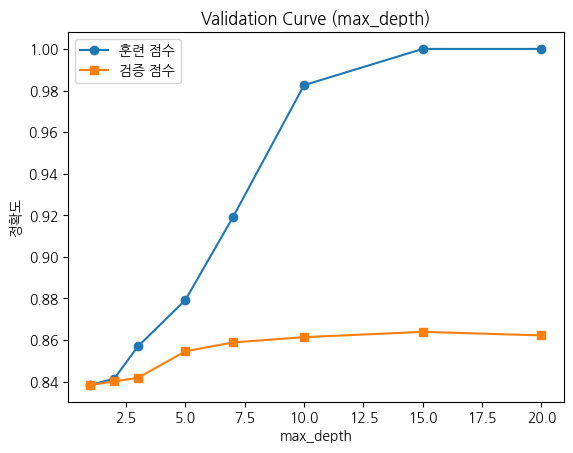

In [53]:
# 코드 입력
from sklearn.model_selection import validation_curve

max_depth_range = [1, 2, 3, 5, 7, 10, 15, 20]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_train, y_train,
    param_name="max_depth", param_range=max_depth_range, cv=5
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(max_depth_range, train_mean, marker="o", label="훈련 점수")
plt.plot(max_depth_range, val_mean, marker="s", label="검증 점수")

plt.xlabel("max_depth")
plt.ylabel("정확도")
plt.title("Validation Curve (max_depth)")

plt.legend()

plt.show()

> 💡 훈련 점수는 계속 올라가는데 검증 점수가 어느 지점부터 정체되거나 떨어진다면, 그 지점 이후로는 과대적합이 시작되고 있다는 신호입니다.

### 3) `learning_curve()` — 데이터 양을 늘려가며 성능 변화 확인

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import learning_curve

train_sizes, train_scores2, val_scores2 = learning_curve(
    RandomForestClassifier(max_depth=5, random_state=42),
    X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean2 = train_scores2.mean(axis=1)
val_mean2 = val_scores2.mean(axis=1)

plt.plot(train_sizes, train_mean2, marker="o", label="훈련 점수")
plt.plot(train_sizes, val_mean2, marker="s", label="검증 점수")
plt.xlabel("훈련 데이터 개수")
plt.ylabel("정확도")
plt.title("Learning Curve")
plt.legend()
plt.show()
```

</details>

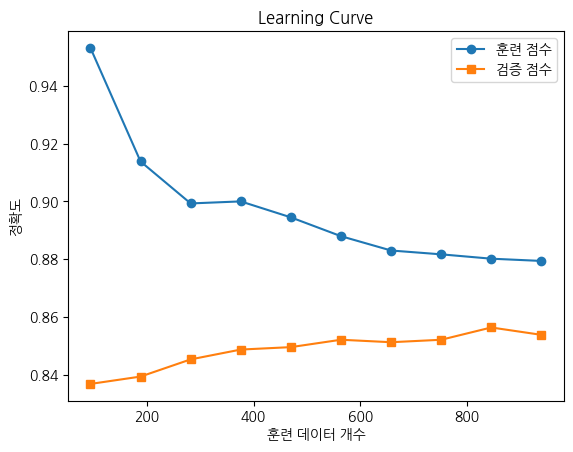

In [54]:
# 코드 입력
from sklearn.model_selection import learning_curve

train_sizes, train_scores2, val_scores2 = learning_curve(
    RandomForestClassifier(max_depth=5, random_state=42),
    X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean2 = train_scores2.mean(axis=1)
val_mean2 = val_scores2.mean(axis=1)

plt.plot(train_sizes, train_mean2, marker="o", label="훈련 점수")
plt.plot(train_sizes, val_mean2, marker="s", label="검증 점수")
plt.xlabel("훈련 데이터 개수")
plt.ylabel("정확도")
plt.title("Learning Curve")
plt.legend()
plt.show()


**Learning Curve로 진단하는 법**

- 훈련 점수와 검증 점수가 **둘 다 낮은 채로 붙어있다** → 편향(과소적합) 문제, 더 복잡한 모델이 필요
- 훈련 점수는 높은데 검증 점수와 **격차가 크다** → 분산(과대적합) 문제, 데이터를 더 모으거나 모델을 단순화
- 데이터가 늘어남에 따라 두 점수가 **점점 가까워지며 둘 다 높아진다** → 이상적인 상황

### 4) GridSearchCV로 최적의 복잡도 찾기

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [3, 5, 7, 10, 15], "n_estimators": [50, 100, 200]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid.best_params_)
print("최고 교차검증 점수:", grid.best_score_)
```

</details>

In [55]:
# 코드 입력
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [3, 5, 7, 10, 15], "n_estimators": [50, 100, 200]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid.best_params_)
print("최고 교차검증 점수:", grid.best_score_)


최적 하이퍼파라미터: {'max_depth': 15, 'n_estimators': 100}
최고 교차검증 점수: 0.8639560043274432


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 훈련/테스트 성능 차이로 최종 모델의 과대적합 여부 재확인
best_model = grid.best_estimator_
print("훈련 정확도:", best_model.score(X_train, y_train))
print("테스트 정확도:", best_model.score(X_test, y_test))
```

</details>

In [56]:
# 훈련/테스트 성능 차이로 최종 모델의 과대적합 여부 재확인

best_model = grid.best_estimator_

print("훈련 정확도:", best_model.score(X_train, y_train))
print("테스트 정확도:", best_model.score(X_test, y_test))

# 훈련 데이터 정확도 100%. 과대적합

훈련 정확도: 1.0
테스트 정확도: 0.8333333333333334


### 5) 서로 다른 진단 도구 비교 — Validation Curve vs Learning Curve

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 두 그래프를 나란히 그려서 각각 무엇을 보여주는지 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(max_depth_range, train_mean, marker="o", label="훈련")
axes[0].plot(max_depth_range, val_mean, marker="s", label="검증")
axes[0].set_xlabel("max_depth (하이퍼파라미터)")
axes[0].set_title("Validation Curve")
axes[0].legend()

axes[1].plot(train_sizes, train_mean2, marker="o", label="훈련")
axes[1].plot(train_sizes, val_mean2, marker="s", label="검증")
axes[1].set_xlabel("훈련 데이터 개수")
axes[1].set_title("Learning Curve")
axes[1].legend()

plt.tight_layout()
plt.show()
```

</details>

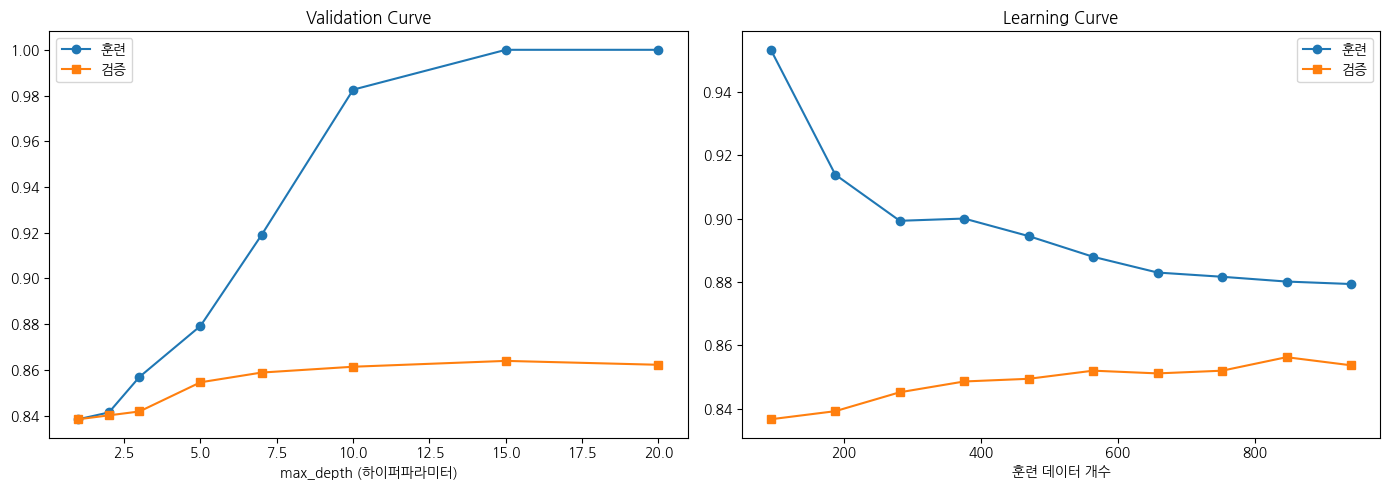

In [57]:
# 코드 입력

# 두 그래프를 나란히 그려서 각각 무엇을 보여주는지 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(max_depth_range, train_mean, marker="o", label="훈련")
axes[0].plot(max_depth_range, val_mean, marker="s", label="검증")
axes[0].set_xlabel("max_depth (하이퍼파라미터)")
axes[0].set_title("Validation Curve")
axes[0].legend()

axes[1].plot(train_sizes, train_mean2, marker="o", label="훈련")
axes[1].plot(train_sizes, val_mean2, marker="s", label="검증")
axes[1].set_xlabel("훈련 데이터 개수")
axes[1].set_title("Learning Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


| 구분 | Validation Curve | Learning Curve |
|---|---|---|
| x축 | 하이퍼파라미터 값 | 훈련 데이터의 개수 |
| 확인하는 것 | "이 하이퍼파라미터를 어떻게 설정해야 하는가" | "데이터를 더 모으면 성능이 좋아지는가" |
| 과대적합 대응 힌트 | 하이퍼파라미터를 더 단순한 방향으로 조정 | 데이터를 더 수집하거나 모델을 단순화 |
| 과소적합 대응 힌트 | 하이퍼파라미터를 더 복잡한 방향으로 조정 | 데이터를 늘려도 소용없을 수 있음 → 모델 자체를 변경 |

> 💡 **핵심 요약**: "하이퍼파라미터를 어떻게 조정해야 할지" 궁금하면 Validation Curve, "데이터를 더 모으는 게 도움이 될지" 궁금하면 Learning Curve를 그려보세요. 두 그래프를 함께 사용하면 문제의 원인(모델 설정 vs 데이터 양)을 훨씬 명확하게 진단할 수 있습니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ 검증 점수가 아니라 훈련 점수만 보고 하이퍼파라미터를 결정하는 경우가 흔합니다 — 훈련 점수는 복잡도가 높아질수록 항상 좋아지므로 판단 기준이 될 수 없습니다.

> ⚠️ Learning Curve에서 데이터를 늘려도 성능이 안 좋아지는 상황(편향 문제)인데도 무조건 데이터를 더 모으려 하는 경우가 있습니다 — 이 경우는 모델 자체를 바꾸거나 복잡도를 높이는 것이 더 효과적입니다.

> ⚠️ Validation Curve와 GridSearchCV 결과가 항상 정확히 일치할 거라 기대하는 경우가 있는데, 탐색 범위와 교차검증 방식에 따라 약간의 차이가 있을 수 있습니다.

---

## 🚀 실무에서는?

> 🚀 실무 모델링에서 "성능이 왜 안 나오는지" 진단할 때 Learning Curve와 Validation Curve를 가장 먼저 그려봅니다. 이를 통해 "데이터 추가 수집"과 "모델/하이퍼파라미터 조정" 중 어디에 리소스를 투입할지 우선순위를 정할 수 있습니다.

---

## 🧩 Check Point

**Q1.** 데이터 양을 늘려가며 성능 변화를 보는 그래프는? ① Validation Curve ② Learning Curve
<details><summary>정답</summary>② Learning Curve</details>

**Q2.** Learning Curve에서 훈련/검증 점수가 둘 다 낮은 채로 붙어있다면 어떤 문제를 의심해야 하나요? ① 과대적합(분산) ② 과소적합(편향)
<details><summary>정답</summary>② 과소적합(편향)</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [ ]:
# TODO 1 (Validation Curve): n_estimators를 [10,50,100,200,300]으로 바꿔가며 Validation Curve를 그리세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.model_selection import validation_curve
n_range = [10, 50, 100, 200, 300]
train_s, val_s = validation_curve(RandomForestClassifier(random_state=42), X_train, y_train,
                                     param_name="n_estimators", param_range=n_range, cv=5)
plt.plot(n_range, train_s.mean(axis=1), marker="o", label="훈련")
plt.plot(n_range, val_s.mean(axis=1), marker="s", label="검증")
plt.legend()
plt.show()
```

</details>

In [ ]:
# 코드 입력





In [ ]:
# TODO 2 (Learning Curve): max_depth=3인 모델의 Learning Curve를 그리세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.model_selection import learning_curve
sizes, train_s2, val_s2 = learning_curve(RandomForestClassifier(max_depth=3, random_state=42),
                                            X_train, y_train, cv=5, train_sizes=np.linspace(0.1,1.0,10))
plt.plot(sizes, train_s2.mean(axis=1), marker="o", label="훈련")
plt.plot(sizes, val_s2.mean(axis=1), marker="s", label="검증")
plt.legend()
plt.show()
```

</details>

In [ ]:
# 코드 입력





In [ ]:
# TODO 3 (진단): 위 두 그래프를 보고 이 모델이 과대적합인지 과소적합인지 판단해보세요




<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답 (관찰 기반 판단, 코드는 훈련/테스트 점수 차이 확인용)
model_check = RandomForestClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print("훈련:", model_check.score(X_train, y_train))
print("테스트:", model_check.score(X_test, y_test))
# 두 점수 차이가 크면 과대적합, 둘 다 낮으면 과소적합 가능성
```

</details>

In [ ]:
# 코드 입력





---

## 📝 실습 과제

In [ ]:
# 코드 입력

# 과제 1: Logistic Regression의 규제 강도(C)를 [0.001, 0.01, 0.1, 1, 10, 100]로
#         바꿔가며 Validation Curve를 그려 최적의 C값을 찾아보세요

# 과제 2: GridSearchCV로 찾은 최적 하이퍼파라미터가 Validation Curve에서 보이는
#         "적절한 지점"과 일치하는지 비교해보세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
from sklearn.linear_model import LogisticRegression
C_range = [0.001, 0.01, 0.1, 1, 10, 100]
train_c, val_c = validation_curve(LogisticRegression(max_iter=10000), X_train, y_train,
                                     param_name="C", param_range=C_range, cv=5)
plt.plot(C_range, train_c.mean(axis=1), marker="o", label="훈련")
plt.plot(C_range, val_c.mean(axis=1), marker="s", label="검증")
plt.xscale("log")
plt.legend()
plt.show()
```

</details>

In [ ]:
# 과제 1 예시 정답





<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
from sklearn.model_selection import GridSearchCV
grid_check = GridSearchCV(RandomForestClassifier(random_state=42),
                            {"max_depth": [3,5,7,10,15,20]}, cv=5)
grid_check.fit(X_train, y_train)
print("GridSearchCV 최적 max_depth:", grid_check.best_params_)
# 위 Validation Curve 그래프에서 검증 점수가 가장 높았던 지점과 비교
```

</details>

In [ ]:
# 과제 2 예시 정답






# 위 Validation Curve 그래프에서 검증 점수가 가장 높았던 지점과 비교

---

## 📌 핵심 정리

- 하이퍼파라미터(max_depth, n_estimators, C 등)로 모델의 편향-분산 균형을 직접 조절
- Validation Curve: 하이퍼파라미터 변화에 따른 성능 변화 확인 → "어떻게 설정할지" 판단
- Learning Curve: 데이터 양 변화에 따른 성능 변화 확인 → "데이터를 더 모을지" 판단
- GridSearchCV로 최적 하이퍼파라미터를 자동 탐색, Validation Curve로 그 결과를 시각적으로 검증

---

# 🎁 CH03-03-B (보너스). K-Means로 내 사진의 색상 팔레트 추출하기

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 사진을 데이터로 변환 → K-Means로 대표색 추출 → 팔레트 시각화 → K색으로 압축한 이미지 비교
> 🔧 **실습파일**: 필요 (`sample_photo.jpg` — 사전 배포, 본인 사진으로 교체 가능)
> ⏱️ **예상 소요시간**: 20~30분
> 🎚️ **난이도**: ★★★☆☆
> 🔗 **사전 지식**: CH03-03-01(K-Means)
> ⏭️ 이 소단원은 진도 상황에 따라 건너뛸 수 있는 보너스이며, 정규 4시간 개념 진도에 포함되지 않습니다.

---

## 🤔 먼저 생각해보기

> **오전에 배운 K-Means는 고객만 그룹핑할 수 있는 게 아닙니다. 사진 한 장은 사실 수만 개의 픽셀, 즉 수만 개의 (R, G, B) 숫자 데이터입니다. 이 픽셀들을 K개의 그룹으로 묶으면 무슨 일이 벌어질까요? — 바로 그 사진의 "대표색 팔레트"가 튀어나옵니다.**

브랜드 컬러 추출, 이미지 압축(GIF가 256색인 이유), 디자인 시안의 배색 분석 — 전부 이 원리입니다. 오전에 배운 코드 그대로, 데이터만 "고객"에서 "픽셀"로 바꿔봅니다.

> ✏️ 먼저 배포된 `sample_photo.jpg`로 실행해보고, 그다음 **본인이 좋아하는 사진**을 같은 폴더에 올려 파일명만 바꿔 다시 실행해보세요. 재미있는 팔레트가 나오면 Zoom 채팅에 자유롭게 공유해주세요!

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 사진을 불러와 작게 리사이즈 (계산 속도를 위해 — 팔레트 추출에는 충분한 크기)
img = Image.open("sample_photo.jpg").resize((160, 105))
plt.imshow(img)
plt.axis("off")
plt.title("원본 사진")
plt.show()

# 사진 → 데이터: (가로×세로) 픽셀들을 (픽셀 수, 3) 형태의 RGB 표로 변환
pixels = np.array(img).reshape(-1, 3)
print("픽셀 데이터 형태:", pixels.shape)   # 각 행이 픽셀 하나의 (R, G, B)
print(pixels[:5])
```

</details>

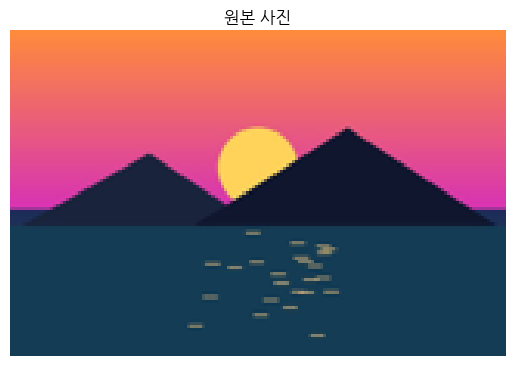

픽셀 데이터 형태: (16800, 3)
[[254 139  60]
 [254 139  60]
 [254 139  60]
 [254 139  60]
 [254 139  60]]


In [58]:
# 코드 입력

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 사진을 불러와 작게 리사이즈 (계산 속도를 위해 — 팔레트 추출에는 충분한 크기)
img = Image.open("sample_photo.jpg").resize((160, 105))
plt.imshow(img)
plt.axis("off")
plt.title("원본 사진")
plt.show()

# 사진 → 데이터: (가로×세로) 픽셀들을 (픽셀 수, 3) 형태의 RGB 표로 변환
pixels = np.array(img).reshape(-1, 3)
print("픽셀 데이터 형태:", pixels.shape)   # 각 행이 픽셀 하나의 (R, G, B)
print(pixels[:5])


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.cluster import KMeans

# 오전과 완전히 같은 코드 — 데이터가 "고객 200명"에서 "픽셀 16,800개"로 바뀌었을 뿐
K = 6
kmeans_img = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_img.fit(pixels)

palette = kmeans_img.cluster_centers_.astype(int)   # 각 그룹의 중심점 = 그 그룹의 대표색
print("추출된 대표색 (RGB):\n", palette)
```

</details>

In [59]:
# 코드 입력

from sklearn.cluster import KMeans

# K-means 모델 학습하기 (K값 6, random_state = 42, n_init = 10)
# 오전과 완전히 같은 코드 — 데이터가 "고객 200명"에서 "픽셀 16,800개"로 바뀌었을 뿐
K = 6
kmeans_img = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_img.fit(pixels)

palette = kmeans_img.cluster_centers_.astype(int)   # 각 그룹의 중심점 = 그 그룹의 대표색
print("추출된 대표색 (RGB):\n", palette)


추출된 대표색 (RGB):
 [[222  71 149]
 [ 21  60  85]
 [253 209  90]
 [ 19  26  51]
 [248 125  77]
 [234  99 113]]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 팔레트 시각화: 각 대표색이 사진에서 차지하는 비중만큼 넓게 표시
counts = np.bincount(kmeans_img.labels_)
order = np.argsort(-counts)   # 많이 쓰인 색 순서로 정렬

fig, ax = plt.subplots(figsize=(10, 2))
left = 0
for i in order:
    width = counts[i] / counts.sum()
    ax.barh(0, width, left=left, color=palette[i] / 255)
    left += width
ax.axis("off")
ax.set_title(f"이 사진의 색상 팔레트 (K={K})")
plt.show()
```

</details>

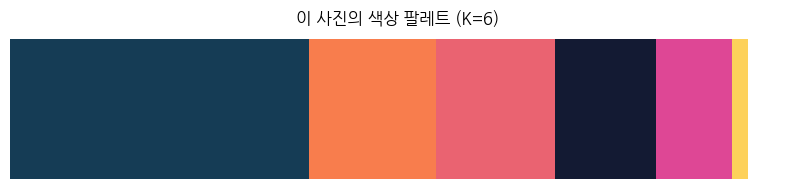

In [60]:
# 팔레트 시각화: 각 대표색이 사진에서 차지하는 비중만큼 넓게 표시

counts = np.bincount(kmeans_img.labels_)
order = np.argsort(-counts)   # 많이 쓰인 색 순서로 정렬

fig, ax = plt.subplots(figsize=(10, 2))

left = 0

for i in order:
    width = counts[i] / counts.sum()
    ax.barh(0, width, left=left, color=palette[i] / 255)
    left += width

ax.axis("off")
ax.set_title(f"이 사진의 색상 팔레트 (K={K})")

plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 모든 픽셀을 자기 그룹의 대표색으로 바꾸면 → "K가지 색만으로 다시 그린" 압축 이미지
compressed = palette[kmeans_img.labels_].reshape(np.array(img).shape).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title("원본")
axes[1].imshow(compressed)
axes[1].set_title(f"K={K}가지 색으로 압축")
for a in axes:
    a.axis("off")
plt.show()
```

</details>

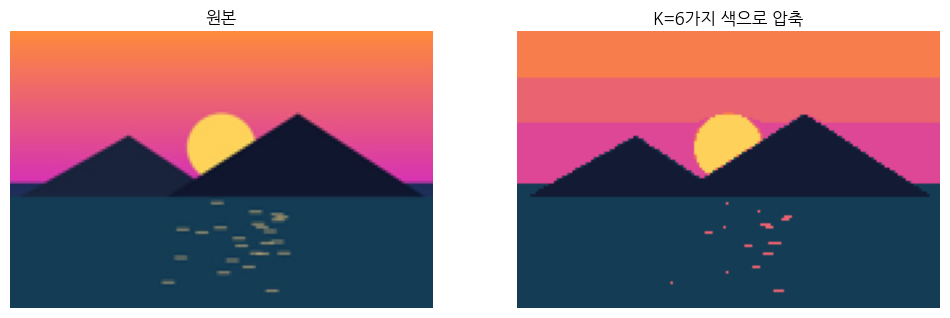

In [61]:
# 코드 입력

# 모든 픽셀을 자기 그룹의 대표색으로 바꾸면 → "K가지 색만으로 다시 그린" 압축 이미지
compressed = palette[kmeans_img.labels_].reshape(np.array(img).shape).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img)
axes[0].set_title("원본")
axes[1].imshow(compressed)
axes[1].set_title(f"K={K}가지 색으로 압축")
for a in axes:
    a.axis("off")
plt.show()


> 🚀 **실무에서는?** 이미지의 색상 수를 줄이는 색 양자화(Color Quantization)는 GIF(256색)·아이콘 최적화 같은 이미지 압축의 기본 원리이고, 디자인 도구들의 "사진에서 배색 추출" 기능도 같은 방식입니다. 오늘 여러분은 마케팅 고객 세분화와 이미지 압축이 **같은 알고리즘 하나**로 풀린다는 것을 확인했습니다 — 이것이 알고리즘을 "원리"로 배우는 이유입니다.

> ✏️ **직접 해보기**: 아래 셀에서 ① 파일명을 본인 사진으로 바꾸거나 ② K를 3, 10 등으로 바꿔 팔레트와 압축 이미지가 어떻게 달라지는지 실험해보세요.

In [ ]:
# 코드 입력

# ✏️ 여기에 나만의 사진/K값으로 바꿔서 실험해보세요


---

## 📌 핵심 정리

- 사진은 (픽셀 수 × RGB 3) 형태의 숫자 데이터로 변환 가능 — K-Means를 그대로 적용할 수 있음
- 클러스터 중심점(cluster_centers_) = 그 그룹의 대표색 → K개의 중심점이 곧 색상 팔레트
- 모든 픽셀을 대표색으로 치환하면 K가지 색만 쓰는 압축 이미지가 됨 (색 양자화)
- 같은 알고리즘이 고객 세분화와 이미지 처리에 모두 쓰임 — 데이터의 형태만 다를 뿐

---
## 🎉 수업 완료!

비지도학습, Feature Importance/Classification Report, GridSearchCV/교차검증, 과적합·과소적합/하이퍼파라미터 4개 소단원을 모두 다뤘습니다. 자율학습(심화: SHAP, Pipeline과 ColumnTransformer)은 `CH03-03-05`, `CH03-03-06` md 문서를 참고해주세요.

다음 챕터인 **CH14(딥러닝-Keras)**로 이어집니다!